In [2]:
import random
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
DATA_DIR = "/home/meduser@quest-global.com/Senthilkumar/project_files/Image_classification/All_datasets/Pistachio_Image_Dataset/Pistachio_Image_Dataset"
WORK_DIR = os.getcwd()

#### Copy File function

In [4]:
def copy_file(from_path, to_path, file):
    if os.path.exists(os.path.join(from_path, file)):
        shutil.copyfile(os.path.join(from_path, file), os.path.join(to_path, file))

#### Explore data

In [5]:
# How many pistachio types we have 
# Save them as list with categories
categories = []
for category_dir in os.listdir(DATA_DIR):
    if os.path.isdir(os.path.join(DATA_DIR, category_dir)):
        categories.append(category_dir)
categories = [category for category in categories if category.endswith("Pistachio")]
print(f"We have {len(categories)} categories of Pistachios : {categories}")

We have 2 categories of Pistachios : ['Siirt_Pistachio', 'Kirmizi_Pistachio']


In [71]:
# Build dataframe with images and labels from both types of pistachio
images_labels_list = []

for category in categories:
    lst = [(file, category) for file in os.listdir(os.path.join(DATA_DIR, category))] 
    images_labels_list += lst
    
pistachio_data = pd.DataFrame(images_labels_list, columns=['id', 'label'])
pistachio_data.head()

,id,label
0,siirt 293.jpg,Siirt_Pistachio
1,siirt 610.jpg,Siirt_Pistachio
2,siirt (41).jpg,Siirt_Pistachio
3,siirt 793.jpg,Siirt_Pistachio
4,siirt 187.jpg,Siirt_Pistachio


In [7]:
# Save created dataframe
pistachio_data_path = os.path.join(WORK_DIR, 'pistachio_data.csv')
pistachio_data.to_csv(pistachio_data_path, index=False)

In [8]:
# Base info about created dataframe
pistachio_data.info()
pistachio_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2148 non-null   object
 1   label   2148 non-null   object
dtypes: object(2)
memory usage: 33.7+ KB


,id,label
0,siirt 293.jpg,Siirt_Pistachio
1,siirt 610.jpg,Siirt_Pistachio
2,siirt (41).jpg,Siirt_Pistachio
3,siirt 793.jpg,Siirt_Pistachio
4,siirt 187.jpg,Siirt_Pistachio


label
Kirmizi_Pistachio    1232
Siirt_Pistachio       916
Name: count, dtype: int64


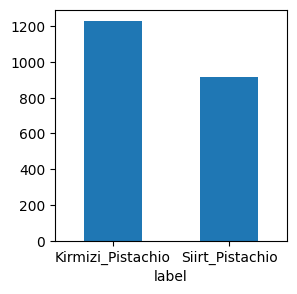

In [9]:
# How many images of each type we have
print(pistachio_data['label'].value_counts())
pistachio_data['label'].value_counts().plot(figsize=(3, 3), kind='bar', rot=0);

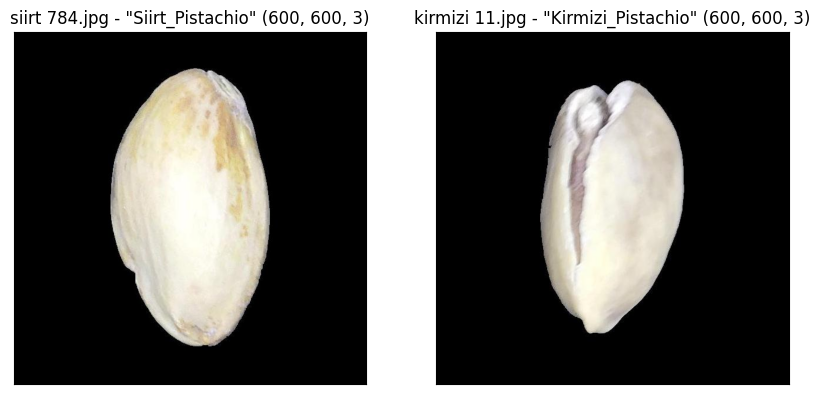

In [10]:
# Prepare plot to show images
fig, axes = plt.subplots(1, len(categories), figsize=(10, 5))
# Save amount of images in each category
categories_count = dict(pistachio_data['label'].value_counts())

# Show image for each category
for i in range(len(categories)):
    category = categories[i]
    
    # Get random image from selected category
    img_num = random.randrange(categories_count[category])
    df = pistachio_data[(pistachio_data['label'] == category)]
    img_name, _ = df.iloc[img_num]
    
    # Open that image
    img_path = os.path.join(DATA_DIR, category, img_name)
    img = plt.imread(img_path)
    
    # Draw plot with that image
    img = plt.imread(img_path)
    axes[i].set_title(f'{img_name} - "{category}" {img.shape}')

    # Hide X and Y axes tick marks
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    
    axes[i].imshow(img)

In [11]:
# Get images and their labels
X = pistachio_data['id']
y = pistachio_data['label']

# Split data into train and val datasets (85% and 15%)
# Usually around 25-33% goes to validations dataset
# But in this case we don't have that much data to efficiently train model, so keep validation dataset smaller
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

# Split train data into train and test datasets (75% and 10%)
# 11% from 85% ~ 10% from 100% 
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.11, random_state=42)

# Train dataset
pistachio_data_train = pd.DataFrame(columns=['id', 'label'])
pistachio_data_train['id'] = X_train
pistachio_data_train['label'] = y_train

# Val dataset
pistachio_data_val = pd.DataFrame(columns=['id', 'label'])
pistachio_data_val['id'] = X_val
pistachio_data_val['label'] = y_val

# Test dataset
pistachio_data_test = pd.DataFrame(columns=['id', 'label'])
pistachio_data_test['id'] = X_test
pistachio_data_test['label'] = y_test

# Check amount of images in each dataset
print('Total images:', len(pistachio_data))
print(f'Train + val + test = {len(pistachio_data_train)} + {len(pistachio_data_val)} + {len(pistachio_data_test)}'
      f' = {len(pistachio_data_train) + len(pistachio_data_val) + len(pistachio_data_test)}')

Total images: 2148
Train + val + test = 1624 + 323 + 201 = 2148


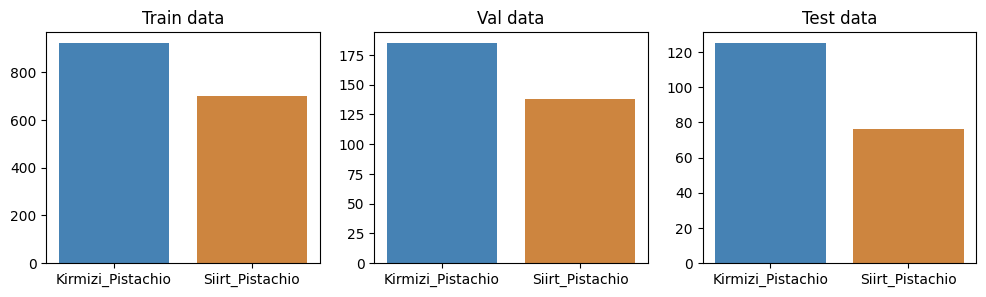

In [12]:
# Create plots for data distribution in train and val datasets
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

train_count = pistachio_data_train['label'].value_counts()
val_count = pistachio_data_val['label'].value_counts()
test_count = pistachio_data_test['label'].value_counts()
colors=['steelblue', 'peru']

axs[0].bar(train_count.index, train_count.values, color=colors)
axs[0].set_title('Train data')

axs[1].bar(val_count.index, val_count.values, color=colors)
axs[1].set_title('Val data')

axs[2].bar(test_count.index, test_count.values, color=colors)
axs[2].set_title('Test data')

plt.show();

In [13]:
pistachio_data_train_path = os.path.join(WORK_DIR, 'pistachio_data_train.csv')
pistachio_data_train.to_csv(pistachio_data_train_path, index=False)

pistachio_data_val_path = os.path.join(WORK_DIR, 'pistachio_data_val.csv')
pistachio_data_val.to_csv('pistachio_data_val.csv', index=False)

pistachio_data_test_path = os.path.join(WORK_DIR, 'pistachio_data_test.csv')
pistachio_data_test.to_csv('pistachio_data_test.csv', index=False)

#### Prepare Test data

In [14]:
TEST_DATA_DIR = os.path.join(WORK_DIR, 'test_data')

# create folder for test data
if not os.path.isdir(TEST_DATA_DIR):
    os.mkdir(TEST_DATA_DIR)
    print('Created folder:', TEST_DATA_DIR)
else:
    print('Folder exists already:', TEST_DATA_DIR)

Folder exists already: /home/meduser@quest-global.com/Senthilkumar/project_files/Image_classification/All_datasets/Pistachio_Image_Dataset/Src_code/test_data


In [15]:
# Copy train data
for i in range(len(pistachio_data_test)):
    copy_file(os.path.join(DATA_DIR, pistachio_data_test.iloc[i]['label']), 
              TEST_DATA_DIR,
              pistachio_data_test.iloc[i]['id'])

# Check that data was copied correctly
file_counter = 0

for file in os.listdir(TEST_DATA_DIR):
    file_counter += 1
    
if len(pistachio_data_test) == file_counter:
    print('Test images were copied succesfully!')
else:
    print('Something went wrong! Folder with test data contains wrong amount of images!')

Test images were copied succesfully!


In [16]:
# Read full data from file
pistachio_data = pd.read_csv('pistachio_data.csv')

# Read train and test data from file
pistachio_data_train = pd.read_csv('pistachio_data_train.csv')
pistachio_data_val = pd.read_csv('pistachio_data_val.csv')
pistachio_data_test = pd.read_csv('pistachio_data_test.csv')

### Prepare boilerplate code for Pytorch

In [17]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision.transforms import v2

# Set GPU as default device for training
# All models will be placed to GPU after creation
# However, some data still needs to be transferred to the GPU manually.
torch.set_default_device('cuda')


# Drawing progress bars
from tqdm import tqdm

In [18]:
# Create a dataset class for storing and processing labeled data (training or validation)
class LabeledImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.images_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.images_labels)

    def __getitem__(self, idx):
        img_name = self.images_labels.iloc[idx]['id']
        label = self.images_labels.iloc[idx]['label']
        categories = list(self.images_labels['label'].unique())
        
        # Images are stored in label-named folders
        img_path = os.path.join(self.img_dir, label, img_name) 
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label=label, categories=categories)
        return image, label

In [19]:
# Dataset class for making predictions on unlabeled data (test).
class UnlabeledImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_list = os.listdir(img_dir)
        
    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        
        img_path = os.path.join(self.img_dir, img_name) 
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image

In [20]:
# Function to encode label for binary image classification
def encode_label_binary(label, categories):
    """
    Function encodes label into 0 or 1 for binary classification 
    
    :label: named label.
    :categories: list with categories we need to classify.
    :return: encoded label.
    """
    # Each label have to be float and in array form
    encoded_label = torch.tensor([float(categories.index(label))])
    return encoded_label

In [21]:
# Function to encode label for multi-class image classification
def encode_label_multi_class(label, categories):
    """
    Function encodes label with one hot encoding for multi-class classification.
    One hot encoding ex.: label='category1', categories=['category0', 'category1', 'category2'], return=[0, 1, 0].
    
    :label: named label.
    :categories: list with categories we need to classify.
    :return: encoded label.
    """
    encoded_label = torch.zeros(len(categories))
    index = categories.index(label)
    encoded_label[index] = 1
    return encoded_label

In [22]:
def calculate_accuracy_binary(outputs, targets):
    """
    Function calculates accuracy of predictions. Outputs are numbers between 0 and 1, and rounded to closest value. 
    After that values compared with targets which are 0 and 1 numbers.
    
    :outputs: tensor array with float values between 0 and 1 - one value per image.
    :targets: tensor array with float ground truth values 0 or 1 - one value per image. 
    :return: accuracy of predictions.
    """
    predicted = torch.round(outputs)
    correct = (predicted == targets).sum().item()  
    total = targets.size(0)
    
    return correct / total

In [23]:
def calculate_accuracy_multi_class(outputs, targets):
    """
    Function calculates accuracy of predictions. Outputs and targets are one hot encoding arrays.
    
    3 categories problem example:
    outputs = [0.9, 0.1, 0.], after torch.max(): _ (max value in outputs) = [0.9], predicted (value position in outputs) = [0]
    targets = [1.0, 0., 0.], , after torch.max(): _ (max value in targets) = [1.], targets (value position in targets) = [0]
    correct = count how many positions were perdicted correcly
    
    :outputs: tensor array with one hot encoded arrays per image.
    :targets: tensor array with one hot encoded arrays per image.
    :return: accuracy of predictions.
    """
    # from sofmax array: max value, max value position
    _, predicted = torch.max(outputs, dim=1)
    # from target array: max value, max value position
    _, targets = torch.max(targets, dim=1)  
    
    # count correct positions
    correct = (predicted == targets).sum().item()  
    total = targets.size(0)
    
    return correct / total

In [24]:
def train_loop(model, dataloader, loss_fn, optimizer, classification_type):
    """
    Function runs train epoch. During this epoch model's weights are tuned. 
    Also it calculates loss and accuracy reaching during this epoch.
    
    :model: Model that gets training.
    :dataloader: Dataloader with training data.
    :loss_fn: loss function used to calculate efficiency of model's predictions.
    :optimizer: optimizer to tune model's weights to increase accuracy of predictions.
    :classification_type: type of classification: binary or multi-class.
    """
    # We need to send data to GPU
    device = torch.device('cuda')
    
    progress_bar = tqdm(total=len(dataloader), ncols=100, position=0, leave=True)
    
    running_loss = 0
    running_accuracy = 0
    
    model.train()

    for images, labels in dataloader:
        # Send data to GPU
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = loss_fn(outputs, labels)
       
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # choose binary or multi-class classification accuracy to calculate
        if classification_type == 'binary':
            running_accuracy += calculate_accuracy_binary(outputs, labels)
        if classification_type == 'multi_class':
            running_accuracy += calculate_accuracy_multi_class(outputs, labels)
        
        progress_bar.update(1)
        
    loss = running_loss / len(dataloader)
    accuracy = running_accuracy / len(dataloader)
        
    progress_bar.close() 
    
    return loss, accuracy

In [25]:
def val_loop(model, dataloader, loss_fn, classification_type):
    """
    Function runs validation epoch. During this epoch tested model's accuracy on data it sees for first time.
    
    :model: Model that gets validation.
    :dataloader: Dataloader with validation data.
    :loss_fn: loss function used to calculate efficiency of model's predictions.
    :classification_type: type of classification: binary or multi-class.
    """
    # We need to send data to GPU
    device = torch.device('cuda')
    
    progress_bar = tqdm(total=len(dataloader), ncols=100, position=0, leave=True)
    
    running_loss = 0
    running_accuracy = 0
    
    model.eval()
    
    with torch.no_grad():
        for images, labels in dataloader:
            # Send data to GPU
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = loss_fn(outputs, labels)
               
            running_loss += loss.item()
            
            # choose binary or multi-class classification accuracy to calculate
            if classification_type == 'binary':
                running_accuracy += calculate_accuracy_binary(outputs, labels)
            if classification_type == 'multi_class':
                running_accuracy += calculate_accuracy_multi_class(outputs, labels)
        
            progress_bar.update(1)
        
    loss = running_loss / len(dataloader)
    accuracy = running_accuracy / len(dataloader)
        
    progress_bar.close() 
    
    return loss, accuracy

In [26]:
class EarlyStopperLoss:
    """
    Class checks reached loss value for model every epoch. If loss value is not improving, it stops model training.
    Also it tells to saves model's weights after improving loss value. 
    """
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        # threshold, if loss get worse (increase) by that value - increase counter
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        
    def update_model_weights(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            return True
        else:
            return False

    def early_stop(self, validation_loss):
        # if you get better loss - reset counter
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        # if you get much worse (by delta value) loss - increase counter
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [27]:
class EarlyStopperAccuracy:
    """
    Class checks reached model's accuracy for every epoch. If accuracy is not improving, it stops model training.
    Also it tells to saves model's weights after improving accuracy. 
    """
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        # threshold, if accuracy get worse (decrease) by that value - increase counter
        self.min_delta = min_delta
        self.counter = 0
        self.max_validation_accuracy = 0
        
    def update_model_weights(self, validation_accuracy):
        if validation_accuracy > self.max_validation_accuracy:
            return True
        else:
            return False

    def early_stop(self, validation_accuracy):
        # if you get better accuracy - reset counter
        if validation_accuracy > self.max_validation_accuracy:
            self.max_validation_accuracy = validation_accuracy
            self.counter = 0

        # if you get much worse (by delta value) accuracy - increase counter
        elif validation_accuracy < (self.max_validation_accuracy - self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [28]:
# List of transformation required for image before it will go to model
transforms = v2.Compose([
    v2.Resize(size=[224, 224], antialias=True), # 600 -> 224
    # ConvertImageDtype will be depricated soon. You will have to use ToDtype instead.
    v2.ConvertImageDtype(torch.float32), # scale pixel values from [0, 255] to [0, 1]
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     v2.ToDtype(torch.float32, scale=True),
])

In [29]:
# Create pytorch datasets using image transformations and label encoding
train_data = LabeledImageDataset(annotations_file='pistachio_data_train.csv', 
                                 img_dir=DATA_DIR,
                                 transform=transforms,
                                 # choose binary or multi-class classification encoder
#                                  target_transform=encode_label_binary, 
                                 target_transform=encode_label_binary,
                                ) 

val_data = LabeledImageDataset(annotations_file='pistachio_data_val.csv',
                               img_dir=DATA_DIR,
                               transform=transforms,
                               # choose binary or multi-class classification encoder
#                                target_transform=encode_label_binary, 
                               target_transform=encode_label_binary,
                              ) 

# Create pytorch dataloaders
# Shuffle training data - it improves training efficiency
train_dataloader = DataLoader(train_data, 
                              batch_size=32, 
                              generator=torch.Generator(device='cuda'),
                              shuffle=True)
val_dataloader = DataLoader(val_data, 
                            batch_size=32, 
                            generator=torch.Generator(device='cuda'),
                            shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3611333].


Feature batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: 32
Label: tensor([1.], device='cuda:0')


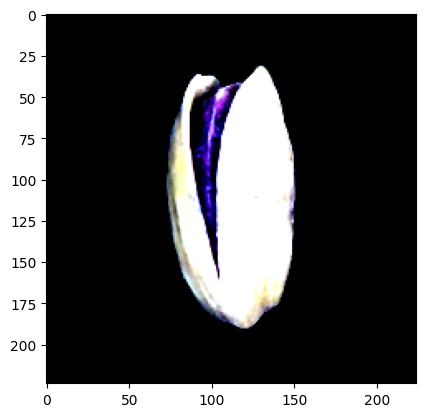

In [30]:
# Check created dataloaders
# Show image and label
train_features, train_labels = next(iter(train_dataloader))
print(f'Feature batch shape: {train_features.size()}')
print(f'Labels batch shape: {len(train_labels)}')
img = train_features[0]
label = train_labels[0]
print(f'Label: {label}')
# PyTorch and Matplotlib have different channels order,  
img = torch.transpose(img, 0, 2) # transpose from [C, W, H] to [H, W, C]
img = torch.transpose(img, 0, 1) # transpose from [H, W, C] to [W, H, C]
plt.imshow(img);

In [31]:
train_labels.shape

torch.Size([32, 1])

In [53]:
from torchvision import models
loss_fn = torch.nn.BCEWithLogitsLoss()

In [64]:
efficent_model = models.efficientnet_b0(pretrained=False)
for param in efficent_model.parameters():
    param.requires_grad = False
efficent_model

/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [65]:
num_ftrs = efficent_model.classifier[1].in_features 
num_ftrs

1280

In [66]:
efficent_model.classifier[1] = nn.Linear(in_features=num_ftrs, out_features=1, bias=True)

In [67]:
for param in efficent_model.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [68]:
efficent_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [69]:
# PyTorch creates model with random weights
seed = 42
torch.manual_seed(seed)
model = efficent_model

In [70]:
num_epochs = 10

# Higher patience than before, because this model is not pretrained
# and has older and less efficient architecture, so it requires longer training.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
early_stopper_accuracy = EarlyStopperAccuracy(patience=5, min_delta=0)

train_stats = []
classification_type = 'binary'
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_loop(model=model, 
                                            dataloader=train_dataloader,
                                            loss_fn=loss_fn,
                                            optimizer=optimizer,
                                            classification_type=classification_type)
        
    val_loss, val_accuracy = val_loop(model=model, 
                                      dataloader=val_dataloader,
                                      loss_fn=loss_fn,
                                      classification_type=classification_type)
    
    result = (
        f'Epoch [{epoch+1}/{num_epochs}], '
        f'Train loss: {train_loss:.4f}, Train accuracy: {train_accuracy:.4f}, '
        f'Val loss: {val_loss:.4f}, Val accuracy: {val_accuracy:.4f}'
    )
        
    print(result)  
    
    # Collect training stats to draw plot later
    train_stats.append((train_loss, train_accuracy, val_loss, val_accuracy))
    
    # # save weights with best results
    # if early_stopper_accuracy.update_model_weights(val_accuracy):   
    #     torch.save(model.state_dict(), ALEXNET_WEIGHTS)
        
    # # early stopping
    # if early_stopper_accuracy.early_stop(val_accuracy): 
    #     break



00%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 19.85it/s]

Epoch [1/10], Train loss: 0.6905, Train accuracy: 0.4291, Val loss: 0.7648, Val accuracy: 0.6080




00%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 20.80it/s]

Epoch [2/10], Train loss: 0.6744, Train accuracy: 0.4583, Val loss: 0.7717, Val accuracy: 0.5909




00%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 20.87it/s]

...

Epoch [8/10], Train loss: 0.6676, Train accuracy: 0.4818, Val loss: 0.7888, Val accuracy: 0.4328




00%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 21.79it/s]

Epoch [9/10], Train loss: 0.6629, Train accuracy: 0.4900, Val loss: 0.7671, Val accuracy: 0.5597



100%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 20.15it/s]

Epoch [10/10], Train loss: 0.6604, Train accuracy: 0.4767, Val loss: 0.7617, Val accuracy: 0.5824


In [130]:
# Validation accuracy is higher than training because dropout layers are not working during model.eval()
train_data_df = pd.DataFrame(train_stats, columns=['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy'])
train_data_df['train_accuracy'] = train_data_df['train_accuracy'] * 100
train_data_df['val_accuracy'] = train_data_df['val_accuracy'] * 100
train_data_df

,train_loss,train_accuracy,val_loss,val_accuracy


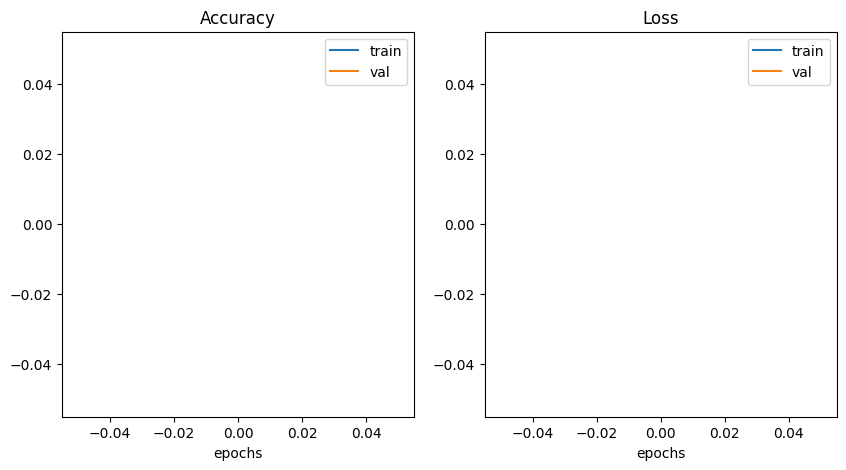

In [52]:
# Draw plots of how the training went
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(train_data_df.index + 1, # fixing epochs starting from 0 instead of 1
             train_data_df[['train_accuracy', 'val_accuracy']])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('epochs')
axes[0].legend(['train', 'val'])
    
axes[1].plot(train_data_df.index + 1, 
             train_data_df[['train_loss', 'val_loss']])
axes[1].set_title('Loss')
axes[1].set_xlabel('epochs')
axes[1].legend(['train', 'val'])

plt.show();

In [67]:
# Load weights of model with best results
model.load_state_dict(torch.load(ALEXNET_WEIGHTS))

<All keys matched successfully>

In [68]:
# Test model on validation data

# We need to send data to GPU
device = torch.device('cuda')

progress_bar = tqdm(total=len(val_dataloader), ncols=100, position=0, leave=True)
    
running_accuracy = 0

model.eval()
    
with torch.no_grad():
    for images, labels in val_dataloader:
        # Send data to GPU
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)

        # choose binary or multi-class classification accuracy to calculate
        if classification_type == 'binary':
            running_accuracy += calculate_accuracy_binary(outputs, labels)
        if classification_type == 'multi_class':
            running_accuracy += calculate_accuracy_multi_class(outputs, labels)
        
        progress_bar.update(1)
        
accuracy = running_accuracy / len(val_dataloader)
        
progress_bar.close() 
    
print('Accuracy of predictions on val data:', accuracy)

100%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 28.52it/s]

Accuracy of predictions on val data: 0.39488636363636365


In [69]:
# Create dataloader for test data
test_data = UnlabeledImageDataset(img_dir=TEST_DATA_DIR,
                                  transform=transforms) 

# Create pytorch dataloaders
test_dataloader = DataLoader(test_data, 
                             batch_size=32,
                             generator=torch.Generator(device='cuda'),
                             shuffle=False,)

In [70]:
# Predict on test data

# We need to send data to GPU
device = torch.device('cuda')

progress_bar = tqdm(total=len(test_dataloader), ncols=100, position=0, leave=True)
prediction_results = []    

model.eval()
    
with torch.no_grad():
    for images in test_dataloader:
        # Send data to GPU
        images = images.to(device)
        
        outputs = model(images)
        
        # choose binary or multi-class classification accuracy to calculate
        # Sigmoid result
        if classification_type == 'binary':
            predicted = torch.round(outputs)
        # Softmax result
        if classification_type == 'multi_class':
            _, predicted = torch.max(outputs, dim=1)
        
        predicted = predicted.tolist()
        prediction_results += predicted
        
        progress_bar.update(1)
        
progress_bar.close()


00%|█████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 30.18it/s]

In [71]:
# Calculate accuracy of predictions

# Check if predictions were made wrong
if len(prediction_results) != len(pistachio_data_test):
    print('Something wrong! "Predictions" contains different amount of images than "pistachio_data_test"')

# Get category names
categories = []

for category_dir in os.listdir(DATA_DIR):
    # Take only subfolders - they contain images
    if os.path.isdir(os.path.join(DATA_DIR, category_dir)):
        categories.append(category_dir)

# Set variable to count correct predictions
correct_predictions = 0

# Get test image names
images_list = [image_name for image_name in os.listdir(TEST_DATA_DIR)]
    
# Count correct predictions
for i in range(len(images_list)):
    # Get image name
    image_name = images_list[i]
    
    # Get predicted label
    if classification_type == 'binary':
        pred_index = int(prediction_results[i][0])
    # Softmax result
    if classification_type == 'multi_class':
        pred_index = prediction_results[i] 
    
    pred_label = categories[pred_index]
    
    # Row orders in 'pistachio_data_test' and 'prediction_results' are different
    # So we have to get groud truth label by image name
    ground_truth_label = pistachio_data_test.loc[pistachio_data_test['id'] == image_name]['label'].item()
    
    if ground_truth_label == pred_label:
        correct_predictions += 1

print('Accuracy of predictions on test data:', correct_predictions / len(prediction_results))

Accuracy of predictions on test data: 0.6268656716417911
